# 03. 환승역 이용 패턴 분석
환승역 목록 확인, 호선별 이용 비중, 혼잡 환승역 TOP10

In [1]:
import sys, os, socket

# 시스템 Spark 3.2.1 vs pip PySpark 3.5.0 충돌 방지
if 'SPARK_HOME' in os.environ:
    old_python = os.path.join(os.environ['SPARK_HOME'], 'python')
    sys.path = [p for p in sys.path if old_python not in p]
    del os.environ['SPARK_HOME']

# Windows: Java 17 경로 자동 설정
if sys.platform == 'win32':
    import subprocess
    result = subprocess.run(['where.exe', 'java'], capture_output=True, text=True)
    if result.stdout.strip():
        java_exe = result.stdout.strip().split('\n')[0].strip()
        os.environ['JAVA_HOME'] = str(os.path.dirname(os.path.dirname(java_exe)))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import socket, os

matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# Windows Spark 설정
LOCAL_IP = socket.gethostbyname(socket.gethostname())
os.environ['SPARK_LOCAL_IP'] = LOCAL_IP
os.environ['HADOOP_HOME'] = 'C:\\hadoop'
os.environ['PATH'] = os.environ['PATH'] + ';C:\\hadoop\\bin'

from delta import configure_spark_with_delta_pip
from pyspark.sql import SparkSession

builder = SparkSession.builder \
    .appName('transfer_analysis') \
    .master('local[1]') \
    .config('spark.driver.host', LOCAL_IP) \
    .config('spark.driver.bindAddress', LOCAL_IP) \
    .config('spark.ui.enabled', 'false') \
    .config('spark.sql.extensions', 'io.delta.sql.DeltaSparkSessionExtension') \
    .config('spark.sql.catalog.spark_catalog', 'org.apache.spark.sql.delta.catalog.DeltaCatalog')

spark = configure_spark_with_delta_pip(builder).getOrCreate()
spark.sparkContext.setLogLevel('ERROR')

In [2]:
# 환승역 목록
df_transfer = spark.read.format('delta').load('data/gold/transfer_stations').toPandas()
print(f'환승역 수: {len(df_transfer)}개')
df_transfer.sort_values('line_count', ascending=False).head(20)

환승역 수: 77개


,subway_sta_nm,line_count
5,김포공항,5
49,서울역,5
73,공덕,4
18,종로3가,3
13,왕십리(성동구청),3
35,고속터미널,3
26,신설동,3
59,디지털미디어시티,3
45,홍대입구,3
71,동대문역사문화공원(DDP),3


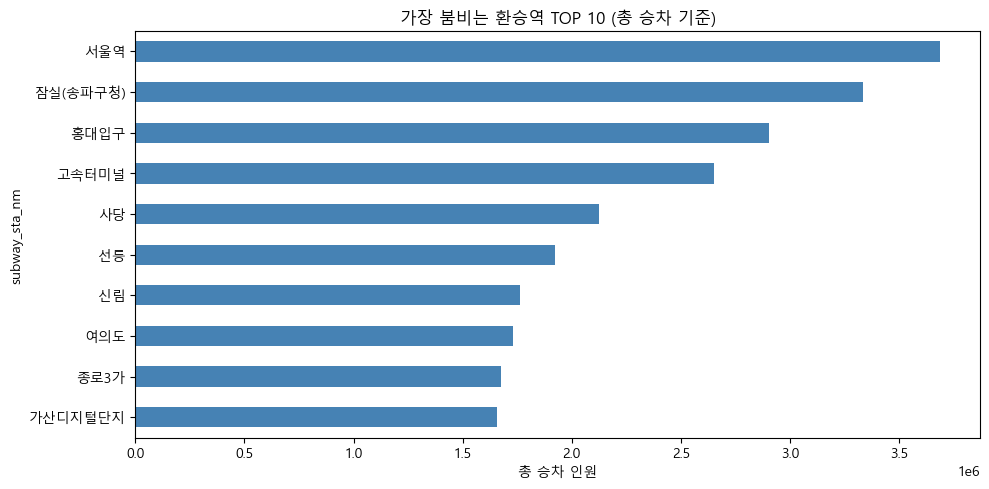

In [3]:
# 환승역 이용 패턴 (호선별 일평균 승하차)
df_pattern = spark.read.format('delta').load('data/gold/transfer_pattern').toPandas()

# 혼잡 환승역 TOP 10 (총 승차 기준)
top10 = df_pattern.groupby('subway_sta_nm')['total_ride'].sum() \
    .sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top10.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('가장 붐비는 환승역 TOP 10 (총 승차 기준)')
ax.set_xlabel('총 승차 인원')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

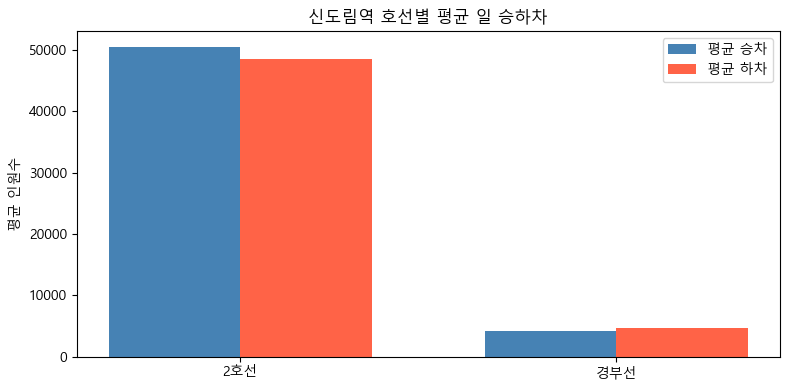

In [4]:
# 특정 환승역 호선별 평균 승하차 비교 (예: 신도림)
station = '신도림'
df_sta = df_pattern[df_pattern['subway_sta_nm'] == station].sort_values('line_num')

x = range(len(df_sta))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([i - width/2 for i in x], df_sta['avg_ride'], width, label='평균 승차', color='steelblue')
ax.bar([i + width/2 for i in x], df_sta['avg_alight'], width, label='평균 하차', color='tomato')
ax.set_xticks(list(x))
ax.set_xticklabels(df_sta['line_num'])
ax.set_title(f'{station}역 호선별 평균 일 승하차')
ax.set_ylabel('평균 인원수')
ax.legend()
plt.tight_layout()
plt.show()

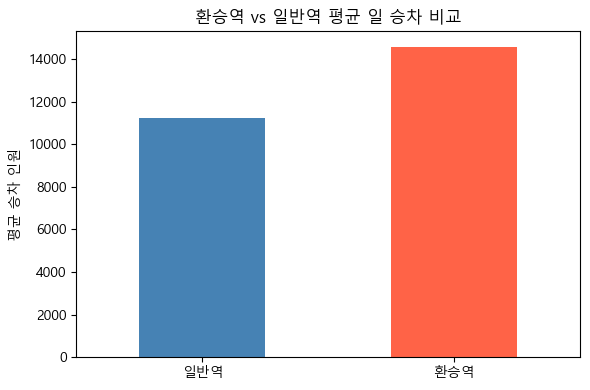

In [5]:
# 환승역 vs 일반역 평균 일 승차 비교
df_daily = spark.read.format('delta').load('data/gold/congestion_daily_avg').toPandas()
transfer_names = df_transfer['subway_sta_nm'].tolist()

df_daily['is_transfer'] = df_daily['subway_sta_nm'].isin(transfer_names)
compare = df_daily.groupby('is_transfer')['avg_ride'].mean()
compare.index = ['일반역', '환승역']

fig, ax = plt.subplots(figsize=(6, 4))
compare.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('환승역 vs 일반역 평균 일 승차 비교')
ax.set_ylabel('평균 승차 인원')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

In [6]:
spark.stop()